<a href="https://colab.research.google.com/github/xiomara-udea/garbage-classification-dataset/blob/main/03_cnn_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **CNN BASELINE - GARBAGE CLASSIFICATION**

## Clasificación de Residuos Sólidos mediante Redes Neuronales Convolucionales

En este notebook se implementa una red neuronal convolucional (CNN) base entrenada desde cero para clasificar residuos sólidos en 10 categorías.

Objetivo:
- Crear una línea base de comparación.
- Evaluar el desempeño de una CNN propia.
- Utilizar Accuracy y F1-Score para medir el rendimiento.

### **Descarga del dataset**

In [ ]:
!kaggle datasets download -d namanjain001/garbage-classification-dataset
!unzip -o -q garbage-classification-dataset.zip

In [20]:
import os

os.path.exists("garbage-classification-dataset.zip")

True

### **Librerías**

In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

### **Parámetros**

In [38]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42
NUM_CLASSES = 10

### **Construir el Dataframe**

In [39]:
dataset_path = "Final Dataset"
data = []

for clase in os.listdir(dataset_path):
    ruta_clase = os.path.join(dataset_path, clase)
    if os.path.isdir(ruta_clase):
        for archivo in os.listdir(ruta_clase):
            data.append({
                "filepath": os.path.join(ruta_clase, archivo),
                "label": clase
            })

df = pd.DataFrame(data)
print(df.shape)
df.head()

(8775, 2)


,filepath,label
0,Final Dataset/trash/trash433.jpg,trash
1,Final Dataset/trash/trash660.jpg,trash
2,Final Dataset/trash/trash5.jpg,trash
3,Final Dataset/trash/trash486.jpg,trash
4,Final Dataset/trash/trash170.jpg,trash


### **Train - Validation - Test**

In [40]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

**Verificación**

In [41]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (6142, 2)
Validation: (1316, 2)
Test: (1317, 2)


### **Codificar clases**

In [42]:
labels = sorted(df["label"].unique())

label_to_index = {
    label:i
    for i,label in enumerate(labels)
}

index_to_label = {
    i:label
    for label,i in label_to_index.items()
}

In [43]:
train_df["label"] = train_df["label"].map(label_to_index)

val_df["label"] = val_df["label"].map(label_to_index)

test_df["label"] = test_df["label"].map(label_to_index)

### **Función de carga**

In [44]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = image / 255.0

    return image, label

### **Crear datasets Tensorflow**

**Entrenamiento**

In [45]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label"].values
    )
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

**Validación**

In [46]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["label"].values
    )
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)

val_ds = val_ds.prefetch(
    tf.data.AUTOTUNE
)

**Test**

In [47]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["label"].values
    )
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

In [48]:
for path in train_df["filepath"].sample(20):
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
    except Exception as e:
        print(path)
        print(e)

### **Arquitectura CNN Baseline**

La arquitectura propuesta está compuesta por:

- 3 bloques convolucionales
- MaxPooling para reducción espacial
- Batch Normalization
- Dropout para reducir overfitting
- Capas densas para clasificación final

Esta red será utilizada como línea base para comparar con arquitecturas preentrenadas.

In [49]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# CNN Baseline
model = Sequential([

    data_augmentation,

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    BatchNormalization(),
    MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Resumen**

In [50]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### **Compilación**

In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### **Callbacks**

In [52]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

### **Entrenamiento**

In [53]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.4598 - loss: 1.6009 - val_accuracy: 0.1672 - val_loss: 2.6458 - learning_rate: 0.0010
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.5399 - loss: 1.3377 - val_accuracy: 0.3100 - val_loss: 1.9615 - learning_rate: 0.0010
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.5689 - loss: 1.2554 - val_accuracy: 0.5821 - val_loss: 1.2397 - learning_rate: 0.0010
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.5904 - loss: 1.1979 - val_accuracy: 0.4802 - val_loss: 1.4673 - learning_rate: 0.0010
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.6143 - loss: 1.1480 - val_accuracy: 0.4688 - val_loss: 1.5570 - learning_rate: 0.0010
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.6162 - loss: 1.1112 - val_accuracy: 0.4757 - val_loss: 1.5579 - learning_rate: 0.0010
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.6483 - loss: 1.

### **Curvas de aprendizaje**

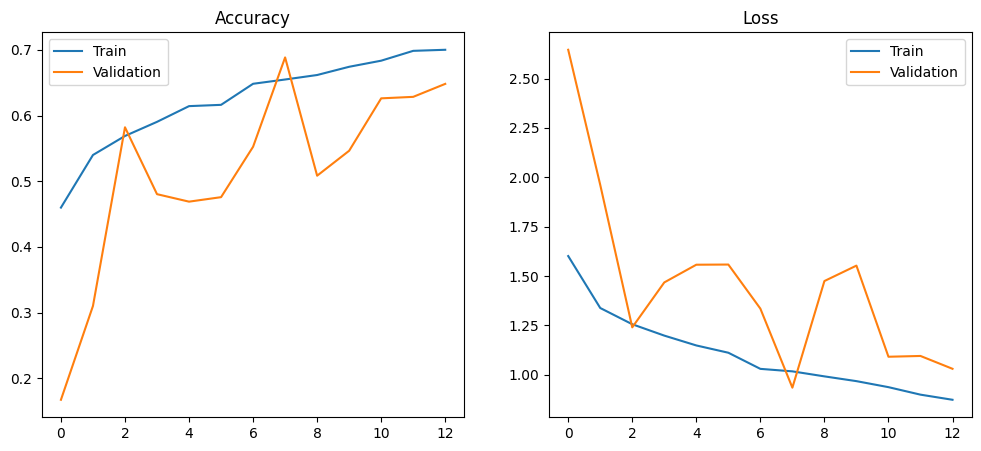

In [54]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

### **Evaluación en test**

In [55]:
test_loss, test_acc = model.evaluate(test_ds)

print("Accuracy:", test_acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 313ms/step - accuracy: 0.6803 - loss: 0.9421
Accuracy: 0.6803340911865234


### **Predicciones**

In [56]:
y_pred = model.predict(test_ds)

y_pred = np.argmax(
    y_pred,
    axis=1
)

42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step


In [57]:
y_true = test_df["label"].values

### **Métricas**

**Accuracy**

In [60]:
acc = accuracy_score(
    y_true,
    y_pred
)

**Precisión**

In [61]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

**Recall**

In [62]:
recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

**F1**

In [63]:
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

In [64]:
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.680334092634776
Precision: 0.6903848624037138
Recall   : 0.680334092634776
F1 Score : 0.6772544929398185


### **Reporte de clasificación**

In [65]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=labels
    )
)

              precision    recall  f1-score   support

     battery       0.67      0.71      0.69       150
  biological       0.81      0.73      0.77       150
 brown-glass       0.84      0.76      0.80       100
   cardboard       0.84      0.83      0.84       150
 green-glass       0.85      0.85      0.85       100
       metal       0.67      0.42      0.52       150
       paper       0.57      0.87      0.69       150
     plastic       0.54      0.60      0.57       150
       trash       0.62      0.49      0.55       100
 white-glass       0.53      0.52      0.52       117

    accuracy                           0.68      1317
   macro avg       0.69      0.68      0.68      1317
weighted avg       0.69      0.68      0.68      1317



### **Matriz de confusión**

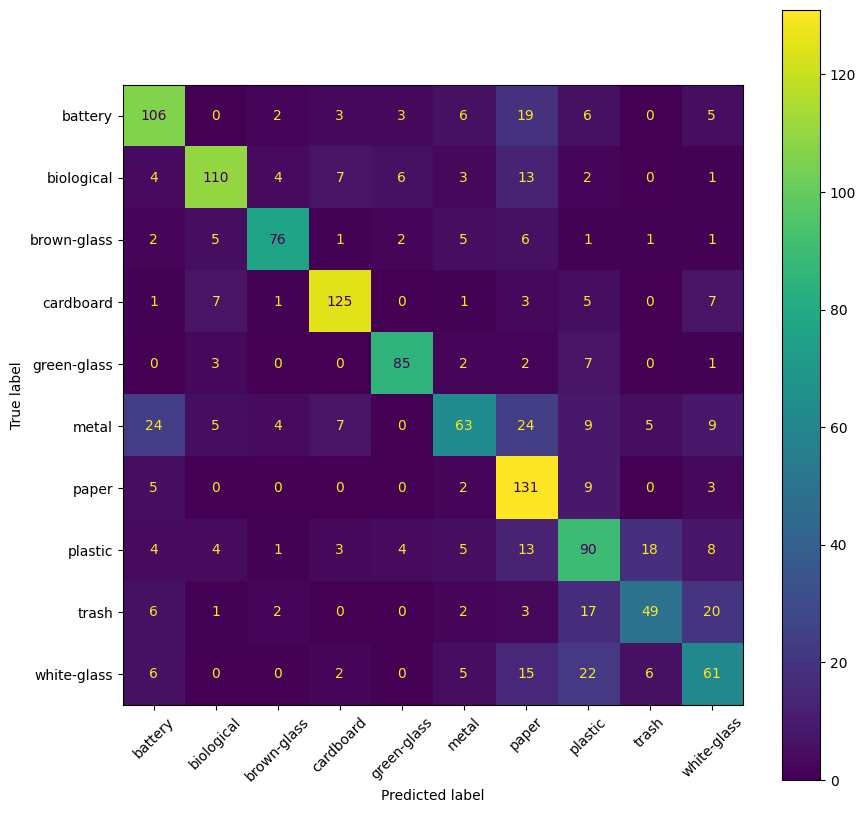

In [85]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()